# Estimación del costo unitario de transformación en órdenes de producción farmacéutica

Se analiza la relación entre las características de órdenes de fabricación de cápsulas duras y su costo unitario de transformación (`costo_transformacion`). Después de excluir cinco órdenes con volumen no positivo y cuatro sin insumos registrados, la población analítica comprende **529 órdenes**, **145 códigos de producto** y **20 periodos contables**. La duración se mide en horas, los costos en pesos colombianos (COP) y el consumo de insumos en kilogramos (kg); el costo objetivo se expresa en COP por unidad producida. La unidad de `volumen_lote` no está especificada en los metadatos disponibles.

El análisis caracteriza la distribución del costo, examina diferencias entre productos y máquinas, y evalúa modelos Ridge bajo dos esquemas de validación. Se distingue entre características disponibles al definir la orden y resultados observados durante su ejecución, pues estos últimos solo permiten una estimación posterior.

**Palabras clave:** costo de transformación, manufactura farmacéutica, cápsulas duras, regresión, órdenes de producción.

## 1. Pregunta y objetivo

> **¿En qué medida las características de producto, volumen, equipo, insumos y modalidad de proceso permiten estimar el costo unitario de transformación de una orden?**

La unidad de análisis es la orden de producción y la respuesta es `costo_transformacion`. El objetivo es estimar el costo a partir de información disponible al especificar la orden, no reconstruir su costo contable después de finalizarla. Las asociaciones exploratorias son descriptivas y no se interpretan causalmente.

## 2. Datos y métodos

Se excluyen las órdenes con `volumen_lote` no positivo y aquellas con `num_insumos` igual a cero o sin información. Las ausencias de `insumo_2` en órdenes con un solo insumo se consideran estructurales. Los costos y las métricas RMSE y MAE se expresan en COP y COP/unidad, respectivamente; la duración está en horas y los consumos en kg.

El análisis comprende: (1) descripción de la población y del costo; (2) asociaciones cuantitativas y diferencias por configuración, categoría de producto y tipo de máquina; (3) un Ridge ampliado con información de ejecución, como diagnóstico; y (4) un Ridge con características disponibles al definir la orden. Se comparan validación aleatoria repetida, que permite productos compartidos entre entrenamiento y prueba, y validación agrupada por código de producto, que evalúa productos no observados durante el ajuste. Los modelos se comparan con una referencia que predice la media del entrenamiento. La elección del esquema pertinente depende del uso previsto.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

candidate_paths = [
    Path("/content/data_costos.csv"),
    Path("data_costos.csv"),
    Path("/mnt/data/data_costos.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data_costos.csv en /content/. Asegúrate de que el archivo esté cargado en la carpeta de contenido de Colab.")

df = pd.read_csv(DATA_PATH, sep=";")
TARGET = "costo_transformacion"
df["volumen_lote"] = pd.to_numeric(df["volumen_lote"], errors="coerce")
n_ordenes_original = len(df)
mask_volumen_valido = df["volumen_lote"] > 0
n_ordenes_excluidas_volumen = int((~mask_volumen_valido).sum())
df = df.loc[mask_volumen_valido].copy()
df["num_insumos"] = pd.to_numeric(df["num_insumos"], errors="coerce")
mask_con_insumos = df["num_insumos"] > 0
n_ordenes_excluidas_sin_insumos = int((~mask_con_insumos).sum())
df = df.loc[mask_con_insumos].copy().reset_index(drop=True)
print(f"Archivo analizado: {DATA_PATH.name}")
print(f"Órdenes originales: {n_ordenes_original:,}")
print(f"Excluidas por volumen no positivo: {n_ordenes_excluidas_volumen}")
print(f"Excluidas por no registrar insumos: {n_ordenes_excluidas_sin_insumos}")
print(f"Población analítica: {df.shape[0]:,} órdenes por {df.shape[1]} variables")


Archivo analizado: data_costos.csv
Órdenes originales: 538
Excluidas por volumen no positivo: 5
Excluidas por no registrar insumos: 4
Población analítica: 529 órdenes por 16 variables


## 3. Resultados

### 3.1 Completitud y estructura

In [2]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes_n": df.isna().sum(),
    "faltantes_pct": (100 * df.isna().mean()).round(1),
    "valores_distintos": df.nunique(dropna=True),
})
display(resumen_calidad)
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Identificadores de orden únicos: {df['id_orden'].nunique()} de {len(df)}")
print(f"Códigos de producto: {df['codigo_producto'].nunique()}")
print(f"Cobertura: {df['periodo'].min()} a {df['periodo'].max()} ({df['periodo'].nunique()} periodos)")

,tipo,faltantes_n,faltantes_pct,valores_distintos
periodo,int64,0,0.0,20
codigo_producto,object,0,0.0,145
id_orden,int64,0,0.0,529
volumen_lote,float64,0,0.0,369
costo_transformacion,float64,0,0.0,527
costo_insumo,float64,0,0.0,525
equipo_id,object,0,0.0,12
tipo_equipo,object,0,0.0,4
categoria_producto,int64,0,0.0,7
num_insumos,int64,0,0.0,2


Filas duplicadas exactas: 0
Identificadores de orden únicos: 529 de 529
Códigos de producto: 145
Cobertura: 202501 a 202608 (20 periodos)


Tras excluir cinco órdenes con volumen de lote no positivo y cuatro órdenes sin insumos registrados, quedan **529 órdenes**. Se observan **145 códigos de producto** y **20 periodos contables**. No quedan órdenes con `num_insumos = 0`; las ausencias de `insumo_2` corresponden a órdenes que registran un solo insumo y se interpretan como ausencia estructural, no como dato faltante aleatorio.

In [3]:
revision_insumos = (df.groupby("num_insumos", dropna=False)
    .agg(ordenes=(TARGET, "size"),
         faltantes_insumo_1=("insumo_1", lambda s: s.isna().sum()),
         faltantes_insumo_2=("insumo_2", lambda s: s.isna().sum()))
    .reset_index())
display(revision_insumos)

,num_insumos,ordenes,faltantes_insumo_1,faltantes_insumo_2
0,1,318,0,318
1,2,211,0,0


Las 318 órdenes con un insumo no registran `insumo_2`, una ausencia estructural de su configuración. Las 211 órdenes con dos insumos tienen ambos campos informados.

### 3.2 Distribución del costo de transformación

---



In [4]:
y = pd.to_numeric(df[TARGET], errors="coerce").dropna()
resumen_objetivo = pd.DataFrame({
    "estadistico": ["n", "media", "desviación estándar", "mínimo", "Q1", "mediana", "Q3", "P95", "P99", "máximo", "asimetría", "ceros"],
    "valor": [len(y), y.mean(), y.std(ddof=1), y.min(), y.quantile(.25), y.median(), y.quantile(.75),
              y.quantile(.95), y.quantile(.99), y.max(), y.skew(), int((y == 0).sum())],
})
resumen_objetivo["valor"] = resumen_objetivo["valor"].round(2)
display(resumen_objetivo)

,estadistico,valor
0,n,529.00
1,media,30.64
2,desviación estándar,15.12
3,mínimo,2.77
4,Q1,22.26
5,mediana,29.14
6,Q3,37.33
7,P95,56.96
8,P99,83.17
9,máximo,97.18


En las **529 órdenes**, el costo unitario tiene media de **30,64 COP/unidad**, mediana de **29,14 COP/unidad** y desviación estándar de **15,12 COP/unidad**. El 50 % central se sitúa entre **22,26 y 37,33 COP/unidad**; el percentil 95 es **56,96** y el máximo **97,18 COP/unidad**. La media por encima de la mediana y la cola hacia valores altos reflejan asimetría positiva.

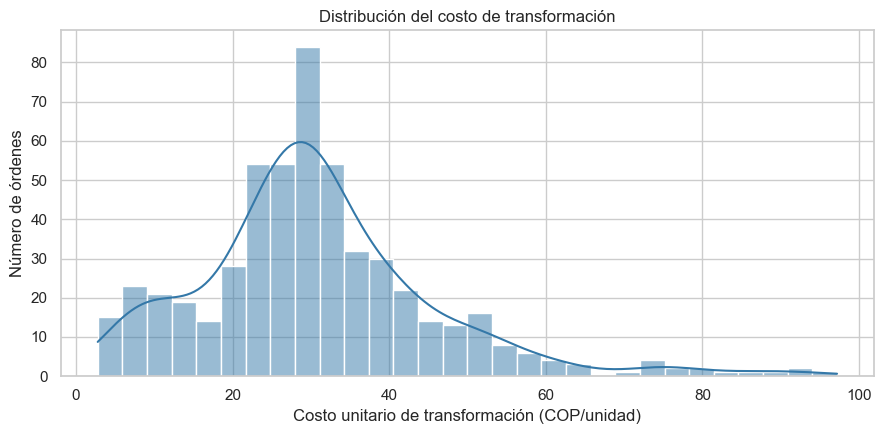

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(y, bins=30, kde=True, ax=ax, color="#3478a8")
ax.set(title="Distribución del costo de transformación", xlabel="Costo unitario de transformación (COP/unidad)", ylabel="Número de órdenes")
plt.tight_layout()

**Prueba de normalidad de la variable objetivo.** Se aplica la prueba de D’Agostino–Pearson, que contrasta conjuntamente asimetría y curtosis. La hipótesis nula establece que la distribución de `costo_transformacion` es normal; la alternativa establece que no lo es. Se usa α = 0,05.

In [2]:
from scipy.stats import normaltest

estadistico_normalidad, p_normalidad = normaltest(y)
print("H₀: la variable objetivo sigue una distribución normal.")
print("H₁: la variable objetivo no sigue una distribución normal.")
print(f"D’Agostino–Pearson: K² = {estadistico_normalidad:.3f}; p = {p_normalidad:.3e}")
print("Decisión (α = 0,05):", "rechazar H₀" if p_normalidad < 0.05 else "no rechazar H₀")

H₀: la variable objetivo sigue una distribución normal.
H₁: la variable objetivo no sigue una distribución normal.
D’Agostino–Pearson: K² = 108.583; p = 2.639e-24
Decisión (α = 0,05): rechazar H₀


El contraste rechaza la normalidad de la distribución marginal del costo (K² = **108,583**; p < **0,001**), en concordancia con la asimetría positiva y la cola hacia valores altos observadas en el histograma.

La distribución concentra muchas órdenes en torno al centro y presenta una cola hacia costos altos, en concordancia con la asimetría positiva. La amplitud de costos respalda examinar si la configuración de producto y proceso ayuda a distinguir órdenes.

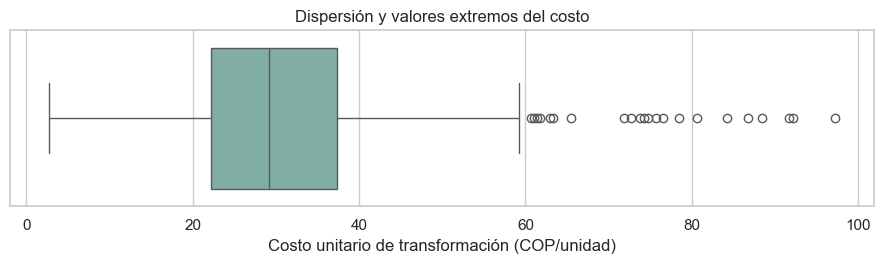

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.8))
sns.boxplot(x=y, ax=ax, color="#79b4a9")
ax.set(title="Dispersión y valores extremos del costo", xlabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

El diagrama confirma la amplitud de la distribución y la presencia de observaciones altas. No se excluyen valores solo por quedar fuera de los bigotes: primero se evalúa si corresponden a configuraciones distintas.

### 3.3 Asociaciones con predictores cuantitativos

In [7]:
variables_cuantitativas = [
    "costo_insumo", "duracion_proceso", "volumen_lote",
    "cantidad_insumo_1", "cantidad_insumo_2", "num_insumos",
]
variables_cuantitativas = [c for c in variables_cuantitativas if c in df.columns]
rho = df[[TARGET] + variables_cuantitativas].corr(method="spearman")[TARGET].drop(TARGET)
tabla_rho = (rho.rename("rho_de_Spearman")
             .to_frame()
             .assign(magnitud=lambda z: z["rho_de_Spearman"].abs())
             .sort_values("magnitud", ascending=False)
             .drop(columns="magnitud")
             .round(3))
display(tabla_rho)

,rho_de_Spearman
costo_insumo,0.360
num_insumos,0.288
volumen_lote,-0.270
duracion_proceso,0.270
cantidad_insumo_2,0.269
cantidad_insumo_1,-0.028


Las asociaciones monotónicas de mayor magnitud con `costo_transformacion` son las de `costo_insumo` (ρ = **0,360**), `num_insumos` (**0,288**), `volumen_lote` (**−0,270**), `duracion_proceso` (**0,270**) y `cantidad_insumo_2` (**0,269**). La asociación con `cantidad_insumo_1` es prácticamente nula (ρ = **−0,028**). Ninguna variable por sí sola resume la variación del costo; estos resultados motivan el análisis multivariable, sin implicar causalidad.

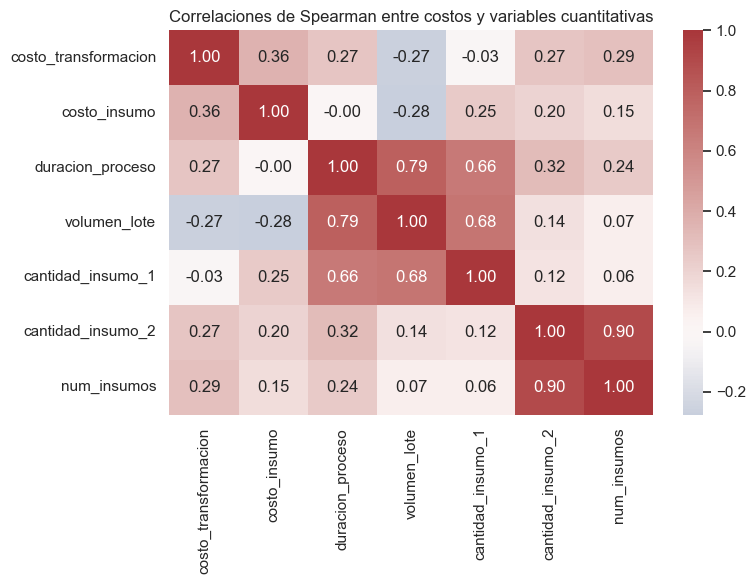

In [8]:
matriz = df[[TARGET] + variables_cuantitativas].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlaciones de Spearman entre costos y variables cuantitativas")
plt.tight_layout()

La matriz permite comparar también las asociaciones entre predictores; estas dependencias deben tenerse en cuenta al interpretar el aporte individual de variables relacionadas.

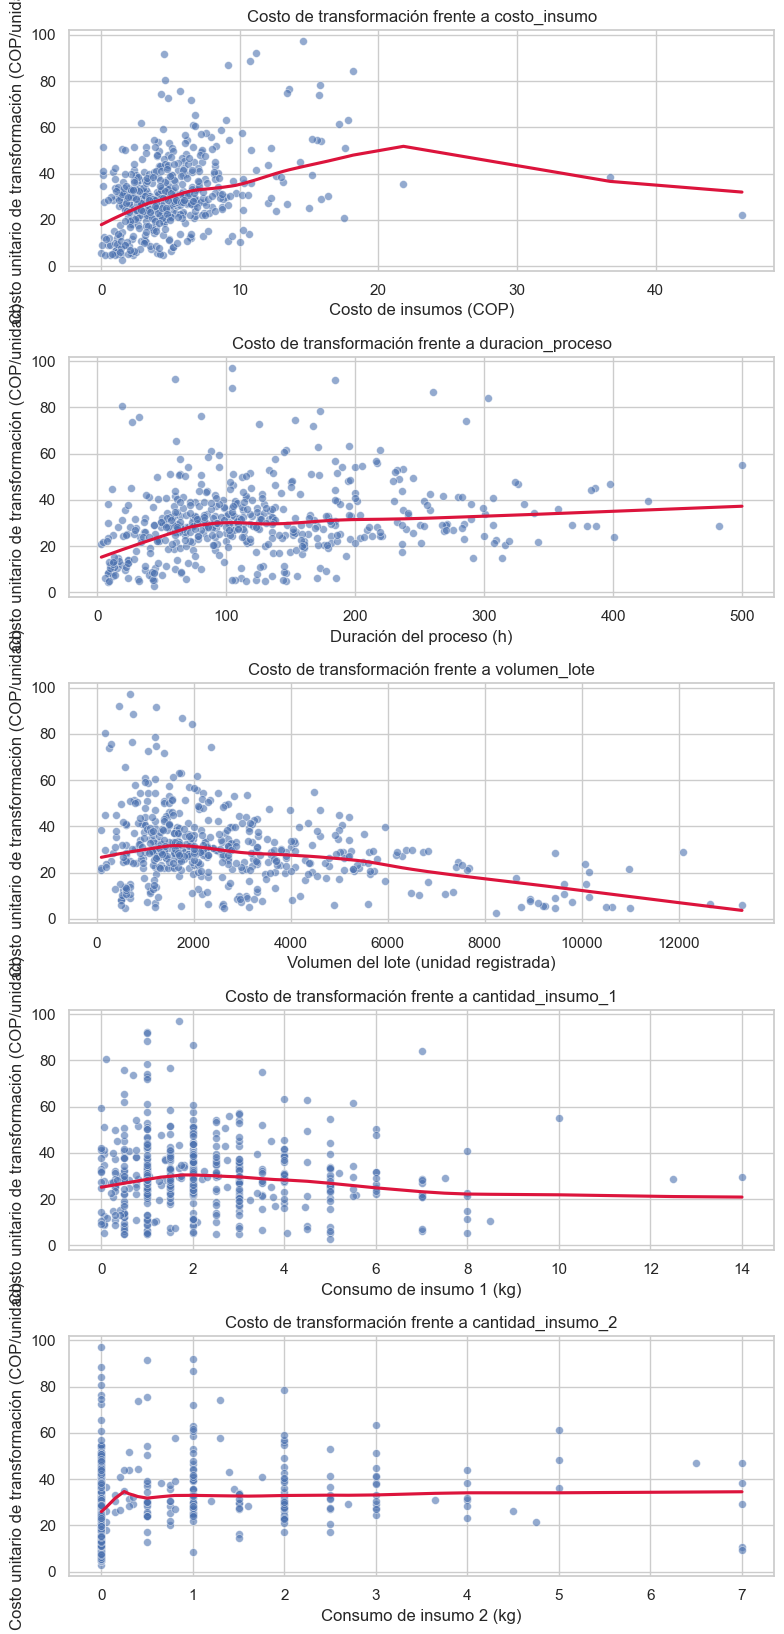

In [9]:
variables_graficos = [
    c for c in ["costo_insumo", "duracion_proceso", "volumen_lote", "cantidad_insumo_1", "cantidad_insumo_2"]
    if c in df.columns
]
fig, axes = plt.subplots(len(variables_graficos), 1, figsize=(8, 3.3 * len(variables_graficos)))
if len(variables_graficos) == 1:
    axes = [axes]
etiquetas_unidad = {"costo_insumo": "Costo de insumos (COP)", "duracion_proceso": "Duración del proceso (h)", "volumen_lote": "Volumen del lote (unidad registrada)", "cantidad_insumo_1": "Consumo de insumo 1 (kg)", "cantidad_insumo_2": "Consumo de insumo 2 (kg)"}
for ax, variable in zip(axes, variables_graficos):
    sns.scatterplot(data=df, x=variable, y=TARGET, alpha=.6, s=32, ax=ax)
    if df[variable].nunique() >= 10:
        sns.regplot(data=df, x=variable, y=TARGET, scatter=False, lowess=True, color="crimson", ax=ax)
    ax.set(title=f"Costo de transformación frente a {variable}", xlabel=etiquetas_unidad.get(variable, variable), ylabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

Los diagramas y las curvas LOWESS muestran una tendencia ascendente entre costo unitario y costo real de insumos, con amplia dispersión. La duración también presenta una tendencia general ascendente, mientras que el costo unitario tiende a disminuir al aumentar el volumen del lote. Las cantidades consumidas muestran patrones menos uniformes. El costo de insumos, la duración y los consumos se observan durante o después de la ejecución; por ello, no forman parte de la especificación principal disponible antes de producir.

### 3.4 Heterogeneidad por equipo y configuración de producción

In [10]:
variables_grupo = ["tipo_equipo", "equipo_id", "modalidad_proceso", "num_insumos"]
filas = []
for variable in variables_grupo:
    tabla = df.groupby(variable, dropna=False)[TARGET].agg(n="count", media="mean", mediana="median", desv_std="std")
    for categoria, estadisticos in tabla.iterrows():
        filas.append({"variable": variable, "categoria": categoria, **estadisticos.to_dict()})
tabla_grupos = pd.DataFrame(filas).sort_values(["variable", "n"], ascending=[True, False])
display(tabla_grupos.round(2))

,variable,categoria,n,media,mediana,desv_std
12,equipo_id,M14,64.0,33.60,30.93,12.21
15,equipo_id,M17,62.0,31.36,30.06,13.26
4,equipo_id,M02,61.0,29.92,28.18,10.74
14,equipo_id,M16,60.0,33.53,29.41,14.46
13,equipo_id,M15,59.0,38.59,35.84,11.78
8,equipo_id,M09,54.0,34.94,30.51,15.93
11,equipo_id,M13,52.0,29.88,28.92,9.24
7,equipo_id,M08,42.0,30.67,29.08,8.80
6,equipo_id,M05,38.0,10.67,10.69,3.75
10,equipo_id,M12,27.0,7.37,7.06,2.42


Las medias de costo unitario (COP/unidad) varían entre tipos de equipo: `A1` **33,37**, `B2` **29,92**, `D4` **9,30** y `C3` **66,81**. `C3` solo reúne diez órdenes. Entre equipos individuales, `M12` promedia **7,37** y `M04` **79,35**, aunque este último se basa en cuatro órdenes. Las medias por modalidad son **29,25** para `X`, **31,66** para `Y` y **41,26** para `Z` (15 órdenes). Las órdenes con dos insumos promedian **35,42**, frente a **27,48** con uno. Estas comparaciones son descriptivas y los grupos pequeños son menos estables.

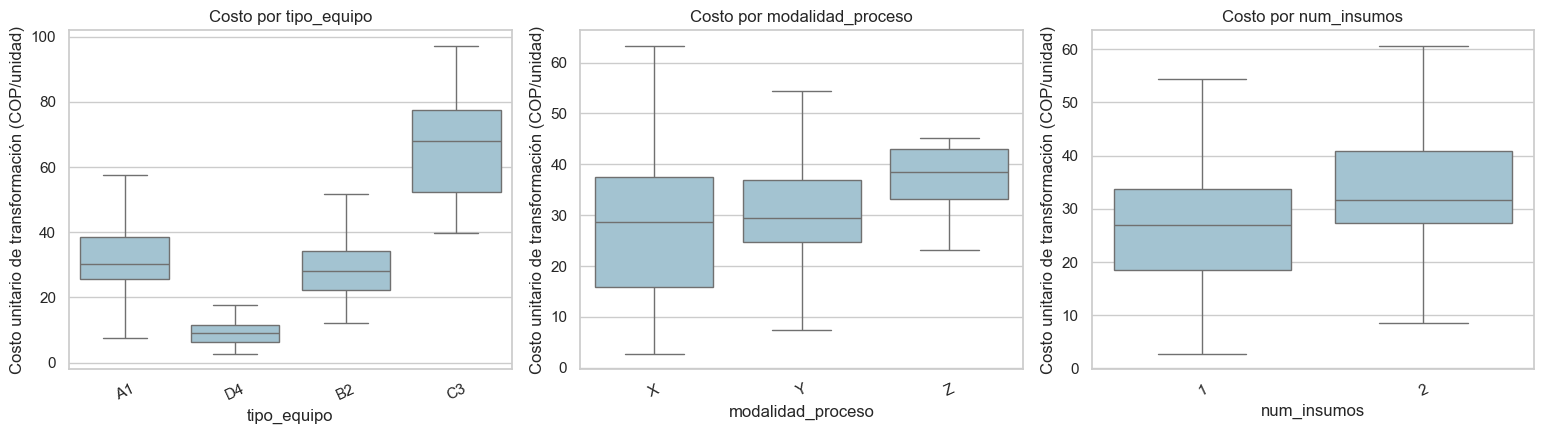

In [11]:
variables_caja = ["tipo_equipo", "modalidad_proceso", "num_insumos"]
fig, axes = plt.subplots(1, len(variables_caja), figsize=(5.2 * len(variables_caja), 4.5))
for ax, variable in zip(axes, variables_caja):
    orden = df[variable].value_counts().index
    sns.boxplot(data=df, x=variable, y=TARGET, order=orden, showfliers=False, ax=ax, color="#9bc6d9")
    ax.set(title=f"Costo por {variable}", xlabel=variable, ylabel="Costo unitario de transformación (COP/unidad)")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

Los diagramas confirman diferencias de ubicación y dispersión por tipo de equipo, modalidad y número de insumos. En particular, la marcada separación entre algunos equipos coincide con el análisis por tipo de máquina; los tamaños desiguales limitan la precisión de las comparaciones.

### 3.5 Variación descriptiva entre periodos

In [12]:
mensual = df.assign(mes=pd.to_datetime(df["periodo"].astype(str), format="%Y%m", errors="coerce"))
mensual = mensual.groupby("mes", as_index=False).agg(
    ordenes=(TARGET, "size"),
    costo_medio=(TARGET, "mean"),
    costo_mediano=(TARGET, "median"),
)
display(mensual.round(2))

,mes,ordenes,costo_medio,costo_mediano
0,2025-01-01,34,32.29,32.97
1,2025-02-01,42,27.76,28.31
2,2025-03-01,20,35.23,29.38
3,2025-04-01,37,28.22,29.66
4,2025-05-01,19,28.91,27.63
5,2025-06-01,24,28.52,28.26
6,2025-07-01,21,31.53,31.21
7,2025-08-01,23,32.84,27.51
8,2025-09-01,16,32.65,30.13
9,2025-10-01,48,26.21,25.28


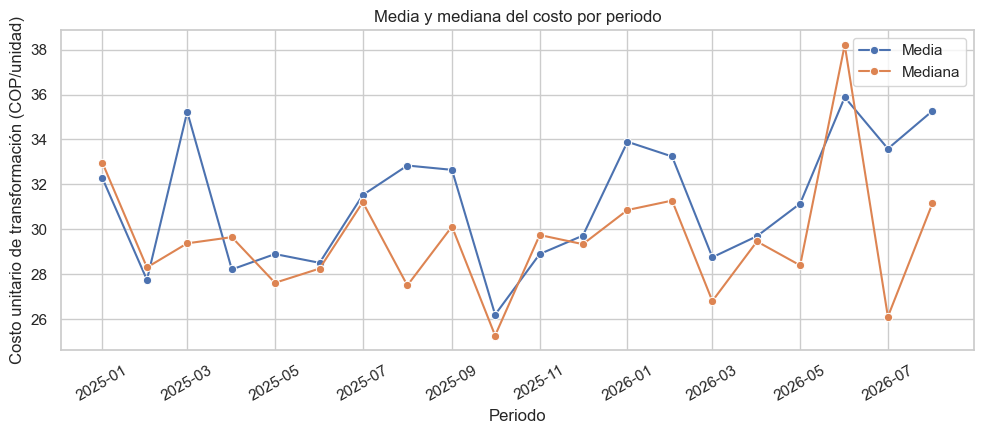

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=mensual, x="mes", y="costo_medio", marker="o", ax=ax, label="Media")
sns.lineplot(data=mensual, x="mes", y="costo_mediano", marker="o", ax=ax, label="Mediana")
ax.set(title="Media y mediana del costo por periodo", xlabel="Periodo", ylabel="Costo unitario de transformación (COP/unidad)")
plt.xticks(rotation=30)
plt.tight_layout()

Las medias y medianas fluctúan entre periodos, sin una tendencia sostenida. El periodo se conserva como contexto descriptivo y se excluye del modelo principal, cuyo propósito es estimar el costo a partir de la configuración de la orden, no pronosticar una serie temporal.

### 3.6 Diferencias descriptivas según categoría de producto

`categoria_producto` se analiza como variable categórica nominal: sus códigos identifican grupos, pero no representan una escala ordenada. Como no se dispone de un diccionario que traduzca los códigos a familias de producto, las categorías se presentan por su código. La tabla resume el tamaño y la distribución del costo unitario de transformación (COP/unidad) en cada grupo.

In [14]:
tabla_categoria_producto = (df.groupby("categoria_producto")[TARGET]
    .agg(n="count", media="mean", desviacion="std", mediana="median",
         Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75))
    .assign(proporcion=lambda t: 100 * t["n"] / t["n"].sum())
    .sort_index())
display(tabla_categoria_producto.round(2))

,n,media,desviacion,mediana,Q1,Q3,proporcion
categoria_producto,,,,,,,
1,12,31.72,9.23,31.85,28.43,35.14,2.27
2,17,36.06,17.46,31.68,28.95,37.38,3.21
3,97,21.63,14.23,21.78,10.45,28.85,18.34
4,36,34.22,9.88,31.18,27.16,39.39,6.81
5,333,32.04,15.40,29.60,22.80,39.01,62.95
6,1,50.22,NaN,50.22,50.22,50.22,0.19
7,33,35.37,9.09,32.85,29.07,39.93,6.24


La categoría 5 concentra la mayor cantidad de órdenes; la categoría 6 tiene una sola observación. Las medianas y dispersiones difieren entre grupos, pero la desproporción de tamaños y el grupo unitario limitan la comparación.

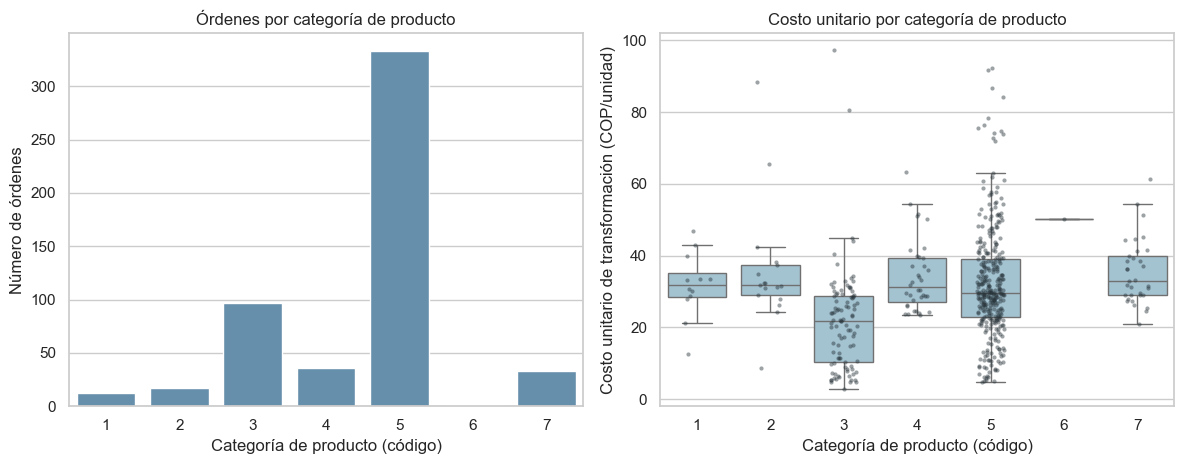

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
orden_categorias = sorted(df["categoria_producto"].dropna().unique())
conteos_categoria = df["categoria_producto"].value_counts().reindex(orden_categorias, fill_value=0)
sns.barplot(x=conteos_categoria.index.astype(str), y=conteos_categoria.values, ax=axes[0], color="#5a91b5")
axes[0].set(title="Órdenes por categoría de producto", xlabel="Categoría de producto (código)", ylabel="Número de órdenes")
sns.boxplot(data=df, x="categoria_producto", y=TARGET, order=orden_categorias,
            showfliers=False, ax=axes[1], color="#9bc6d9")
sns.stripplot(data=df, x="categoria_producto", y=TARGET, order=orden_categorias,
              color="#263238", alpha=.45, size=3, jitter=.18, ax=axes[1])
axes[1].set(title="Costo unitario por categoría de producto", xlabel="Categoría de producto (código)", ylabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

El gráfico confirma el desbalance y muestra variación de costos dentro y entre categorías. La categoría 6 aparece como un punto aislado y no permite estimar variabilidad propia.

In [16]:
from scipy.stats import kruskal

muestras_categoria = [g[TARGET].dropna().to_numpy() for _, g in df.groupby("categoria_producto")]
H_kruskal, p_kruskal = kruskal(*muestras_categoria)
n_kw = sum(map(len, muestras_categoria))
k_kw = len(muestras_categoria)
epsilon2_kruskal = max(0, (H_kruskal - k_kw + 1) / (n_kw - k_kw))
print(f"Kruskal-Wallis: H={H_kruskal:.3f}; gl={k_kw-1}; p={p_kruskal:.3e}")
print(f"Tamaño de efecto epsilon-cuadrado: {epsilon2_kruskal:.3f}")

Kruskal-Wallis: H=64.879; gl=6; p=4.566e-12
Tamaño de efecto epsilon-cuadrado: 0.113


Kruskal–Wallis contrasta globalmente si las distribuciones son iguales entre categorías. El resultado significativo (H = 64,879; gl = 6; p < 0,001; ε² = 0,113) indica diferencias entre al menos algunos grupos, pero no identifica cuáles. Por el desbalance y el grupo unitario no se realizan comparaciones por pares. El contraste no ajusta por equipo, volumen ni configuración de insumos.

### 3.7 Diferencias descriptivas según tipo de máquina

`tipo_equipo` identifica la familia o tipo de máquina, mientras que `equipo_id` identifica equipos individuales. Se trata de variables relacionadas, aunque describen niveles distintos de la configuración. La tabla resume el costo unitario de transformación (COP/unidad) por tipo de máquina, incluyendo tamaño de grupo, media, desviación estándar, mediana y rango intercuartílico.

In [17]:
tabla_tipo_maquina = (df.groupby("tipo_equipo")[TARGET]
    .agg(n="count", media="mean", desviacion="std", mediana="median",
         Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75))
    .assign(proporcion=lambda t: 100 * t["n"] / t["n"].sum())
    .sort_index())
display(tabla_tipo_maquina.round(2))

,n,media,desviacion,mediana,Q1,Q3,proporcion
tipo_equipo,,,,,,,
A1,393,33.37,12.82,30.38,25.72,38.52,74.29
B2,61,29.92,10.74,28.18,22.26,34.35,11.53
C3,10,66.81,17.69,68.02,52.49,77.54,1.89
D4,65,9.30,3.63,8.96,6.25,11.52,12.29


El costo medio por tipo de máquina va de **9,30 COP/unidad** (`D4`) a **66,81 COP/unidad** (`C3`); la desviación estándar de `C3` se estima con solo diez órdenes. Los tamaños muestrales deben acompañar la lectura de medias y dispersiones.

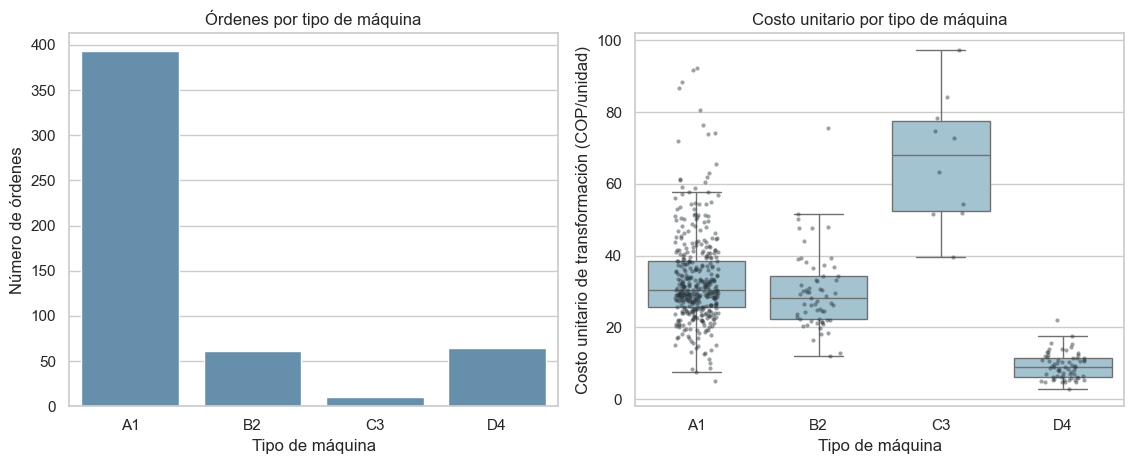

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
orden_maquinas = sorted(df["tipo_equipo"].dropna().unique())
conteos_maquina = df["tipo_equipo"].value_counts().reindex(orden_maquinas, fill_value=0)
sns.barplot(x=conteos_maquina.index.astype(str), y=conteos_maquina.values, ax=axes[0], color="#5a91b5")
axes[0].set(title="Órdenes por tipo de máquina", xlabel="Tipo de máquina", ylabel="Número de órdenes")
sns.boxplot(data=df, x="tipo_equipo", y=TARGET, order=orden_maquinas,
            showfliers=False, ax=axes[1], color="#9bc6d9")
sns.stripplot(data=df, x="tipo_equipo", y=TARGET, order=orden_maquinas,
              color="#263238", alpha=.45, size=3, jitter=.18, ax=axes[1])
axes[1].set(title="Costo unitario por tipo de máquina", xlabel="Tipo de máquina", ylabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

`A1` concentra la mayoría de las órdenes; `C3` es mucho menos frecuente. El costo se ubica en niveles bajos para `D4` y altos para `C3`, mientras `A1` y `B2` tienen medianas más próximas. El contraste entre `C3` y `D4` debe leerse considerando sus diferentes frecuencias.

In [19]:
muestras_tipo_maquina = [g[TARGET].dropna().to_numpy() for _, g in df.groupby("tipo_equipo")]
H_maquina, p_maquina = kruskal(*muestras_tipo_maquina)
n_maquina = sum(map(len, muestras_tipo_maquina))
k_maquina = len(muestras_tipo_maquina)
epsilon2_maquina = max(0, (H_maquina - k_maquina + 1) / (n_maquina - k_maquina))
print(f"Kruskal-Wallis: H={H_maquina:.3f}; gl={k_maquina-1}; p={p_maquina:.3e}")
print(f"Tamaño de efecto epsilon-cuadrado: {epsilon2_maquina:.3f}")

Kruskal-Wallis: H=185.417; gl=3; p=5.964e-40
Tamaño de efecto epsilon-cuadrado: 0.347


Kruskal–Wallis detecta diferencias globales entre tipos de máquina (H = 185,417; gl = 3; p < 0,001; ε² = 0,347). La prueba no identifica pares distintos ni ajusta por producto, volumen, insumos o modalidad; por tanto, no representa un efecto causal de la máquina.

## 4. Ridge ampliado como diagnóstico

Este Ridge incluye las variables disponibles salvo `id_orden`, entre ellas `duracion_proceso`, `costo_insumo` y los consumos reales. Por tanto, evalúa una pregunta posterior a la ejecución y no constituye el estimador operativo definido en la sección 5.

La selección de α se realiza mediante validación interna sobre el pipeline completo: imputación, escalamiento y codificación se ajustan dentro de cada pliegue. En validación agrupada, también se agrupan los pliegues internos por código de producto. Se comparan validación aleatoria repetida de 5 pliegues y 3 repeticiones con validación externa agrupada por `codigo_producto`. La referencia predice la media del costo de entrenamiento.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ALPHAS = np.logspace(-3, 5, 17)

def construir_pipeline_ridge(X):
    categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
    # categoria_producto es un código entero nominal, no una escala cuantitativa.
    if "categoria_producto" in X.columns and "categoria_producto" not in categoricas:
        categoricas.append("categoria_producto")
    numericas = [columna for columna in X.columns if columna not in categoricas]
    preprocesamiento = ColumnTransformer([
        ("numericas", Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("estandarizar", StandardScaler()),
        ]), numericas),
        ("categoricas", Pipeline([
            ("imputar", SimpleImputer(strategy="constant", fill_value="__AUSENTE__")),
            ("indicadores", OneHotEncoder(handle_unknown="ignore")),
        ]), categoricas),
    ])
    return Pipeline([("preprocesamiento", preprocesamiento), ("ridge", Ridge())])

def evaluar_ridge_anidado(X, y, pliegues_externos, esquema, grupos=None, etiqueta="Ridge"):
    """Ajusta todo el pipeline en los pliegues internos y evalúa en pliegues externos."""
    filas = []
    for pliegue, (idx_train, idx_test) in enumerate(pliegues_externos, start=1):
        if esquema == "agrupada":
            grupos_train = grupos.iloc[idx_train]
            cv_interna = GroupKFold(n_splits=3)
        else:
            grupos_train = None
            cv_interna = KFold(n_splits=3, shuffle=True, random_state=17)
        busqueda = GridSearchCV(
            estimator=construir_pipeline_ridge(X.iloc[idx_train]),
            param_grid={"ridge__alpha": ALPHAS},
            scoring="neg_mean_squared_error",
            cv=cv_interna,
            n_jobs=1,
            refit=True,
        )
        busqueda.fit(
            X.iloc[idx_train], y.iloc[idx_train],
            **({"groups": grupos_train} if grupos_train is not None else {}),
        )
        pred = busqueda.predict(X.iloc[idx_test])
        media = np.full(len(idx_test), y.iloc[idx_train].mean())
        for modelo, estimado in [(etiqueta, pred), ("Media de entrenamiento", media)]:
            filas.append({
                "validacion": esquema,
                "pliegue": pliegue,
                "modelo": modelo,
                "RMSE": np.sqrt(mean_squared_error(y.iloc[idx_test], estimado)),
                "MAE": mean_absolute_error(y.iloc[idx_test], estimado),
                "R_cuadrado": r2_score(y.iloc[idx_test], estimado),
                "alpha": busqueda.best_params_["ridge__alpha"] if modelo == etiqueta else np.nan,
            })
    return pd.DataFrame(filas)

TARGET = "costo_transformacion"
y_modelo = pd.to_numeric(df[TARGET], errors="coerce")
X_ampliado = df.drop(columns=[TARGET, "id_orden"]).copy()
grupos_producto = df["codigo_producto"].astype(str)
pliegues_aleatorios = list(RepeatedKFold(n_splits=5, n_repeats=3, random_state=42).split(X_ampliado, y_modelo))
pliegues_producto = list(GroupKFold(n_splits=5).split(X_ampliado, y_modelo, groups=grupos_producto))

resultados_ampliado = pd.concat([
    evaluar_ridge_anidado(X_ampliado, y_modelo, pliegues_aleatorios, "aleatoria", etiqueta="Ridge ampliado"),
    evaluar_ridge_anidado(X_ampliado, y_modelo, pliegues_producto, "agrupada", grupos=grupos_producto, etiqueta="Ridge ampliado"),
], ignore_index=True)
tabla_modelo = (resultados_ampliado
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .agg(["mean", "std"]).round(2))
display(tabla_modelo)

RMSE          MAE       R_cuadrado      
                                    mean   std   mean   std       mean   std
validacion modelo                                                           
agrupada   Media de entrenamiento  15.48  2.49  11.25  2.00      -0.23  0.12
           Ridge ampliado          10.54  1.97   7.45  1.30       0.43  0.08
aleatoria  Media de entrenamiento  15.12  0.70  10.83  0.54      -0.01  0.02
           Ridge ampliado           9.24  1.09   6.26  0.62       0.62  0.06

## 5. Modelo basado en la configuración de la orden

El modelo operativo se limita a variables conocidas al definir la orden: producto, volumen, equipo, insumos y modalidad. Se excluyen duración, costo de insumos y cantidades consumidas porque describen la ejecución real; incluirlas cambiaría la pregunta a una explicación retrospectiva del costo.

### 5.1 Selección de predictores

La especificación principal (A) prioriza variables disponibles al definir la orden. Las especificaciones A y B permiten evaluar variables con información solapada sin asumir de antemano que sean inútiles.

| Variable | Especificación A | Criterio |
|---|---:|---|
| `codigo_producto` | Sí | Identifica el producto específico. |
| `categoria_producto` | Sí | Describe una agrupación distinta del código específico; su distribución y su asociación con el costo se exploran en la sección 3.6. |
| `volumen_lote` | Sí | Representa la escala de la orden; su unidad no está especificada. |
| `equipo_id` | Sí | Identifica el equipo individual asignado. |
| `tipo_equipo` | No; se añade en B | Está relacionado con `equipo_id`, pero describe su familia. La sección 3.7 muestra diferencias entre tipos; por eso se evalúa en B en vez de descartarlo como irrelevante. |
| `insumo_1`, `insumo_2` | Sí | Describen la composición de insumos; la ausencia de `insumo_2` es estructural en órdenes de un insumo. |
| `num_insumos` | No; se añade en B | Resume la configuración ya reflejada parcialmente por los campos de insumo; se evalúa conjuntamente con `tipo_equipo`. |
| `modalidad_proceso` | Sí | Describe la modalidad prevista de operación. |
| `duracion_proceso`, `costo_insumo`, cantidades consumidas | No | Son resultados observados durante o después de la ejecución. |
| `periodo`, `id_orden` | No | El periodo no forma parte de la pregunta operativa y el identificador no tiene significado predictivo propio. |

La comparación A/B evalúa el aporte conjunto de `tipo_equipo` y `num_insumos`; no permite atribuir la diferencia a uno de ellos por separado.

### 5.2 Especificación evaluada

El costo unitario de transformación se estima con `codigo_producto`, `categoria_producto`, `volumen_lote`, `equipo_id`, `insumo_1`, `insumo_2` y `modalidad_proceso` (especificación A). La variante B añade `tipo_equipo` y `num_insumos`.

In [21]:
TARGET = "costo_transformacion"

FEATURES_A = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
    "insumo_1", "insumo_2", "modalidad_proceso",
]
FEATURES_REDUNDANTES = ["tipo_equipo", "num_insumos"]
FEATURES_B = FEATURES_A + FEATURES_REDUNDANTES

print("Variable objetivo:", TARGET)
print("Modelo A: características seleccionadas, sin las variables consideradas redundantes")
print("Modelo B: mismas características más tipo_equipo y num_insumos")
print("Predictores redundantes añadidos:", FEATURES_REDUNDANTES)

Variable objetivo: costo_transformacion
Modelo A: características seleccionadas, sin las variables consideradas redundantes
Modelo B: mismas características más tipo_equipo y num_insumos
Predictores redundantes añadidos: ['tipo_equipo', 'num_insumos']


### 5.3 Comparación de especificaciones a la luz del EDA

El análisis exploratorio muestra diferencias de costo entre categorías de producto y, con mayor separación descriptiva, entre tipos de máquina. Los contrastes son globales y no ajustados; la categoría de producto 6 tiene una observación y el tipo `C3`, diez. `equipo_id` y `tipo_equipo` describen niveles relacionados —equipo individual y familia—, mientras código y categoría de producto identifican niveles distintos.

La comparación A/B añade conjuntamente `tipo_equipo` y `num_insumos` a la especificación A. Permite valorar su aporte combinado, pero no aislar la contribución de cada variable. La interpretación de los resultados considera esta limitación y el desempeño bajo ambos esquemas de validación.

In [22]:
X_A = df[FEATURES_A].copy()
X_B = df[FEATURES_B].copy()
y_modelo_new = pd.to_numeric(df[TARGET], errors="coerce")

resultados_comparacion = []
for nombre, X_especificacion in [("A: sin redundantes", X_A), ("B: con redundantes", X_B)]:
    resultados_comparacion.append(evaluar_ridge_anidado(
        X_especificacion, y_modelo_new, pliegues_aleatorios, "aleatoria", etiqueta=nombre
    ))
    resultados_comparacion.append(evaluar_ridge_anidado(
        X_especificacion, y_modelo_new, pliegues_producto, "agrupada",
        grupos=grupos_producto, etiqueta=nombre
    ))
resultados_comparacion = pd.concat(resultados_comparacion, ignore_index=True)
# La referencia de la media es idéntica en A y B; conservar una sola copia por pliegue.
resultados_comparacion = resultados_comparacion.drop_duplicates(
    subset=["validacion", "pliegue", "modelo"]
)
tabla_comparacion = (resultados_comparacion
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .agg(["mean", "std"]).round(2))
display(tabla_comparacion)

# Diferencia media de las métricas para valorar el aporte de las variables añadidas.
resumen_comparacion = (resultados_comparacion
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .mean().round(3).reset_index())
display(resumen_comparacion)
# Diferencias pareadas B − A sobre los mismos pliegues externos.
metricas_pareadas = []
for metrica in ["RMSE", "MAE", "R_cuadrado"]:
    ancho = (resultados_comparacion[resultados_comparacion["modelo"].isin(["A: sin redundantes", "B: con redundantes"])]
        .pivot(index=["validacion", "pliegue"], columns="modelo", values=metrica))
    delta = ancho["B: con redundantes"] - ancho["A: sin redundantes"]
    tmp = delta.rename(f"delta_B_menos_A_{metrica}").reset_index()
    metricas_pareadas.append(tmp)
diferencias_plegadas = metricas_pareadas[0]
for tmp in metricas_pareadas[1:]:
    diferencias_plegadas = diferencias_plegadas.merge(tmp, on=["validacion", "pliegue"])
columnas_delta = [col for col in diferencias_plegadas.columns if col.startswith("delta_")]
tabla_diferencias = (diferencias_plegadas.groupby("validacion")[columnas_delta]
    .agg(["mean", "std"]).round(3))
display(tabla_diferencias)


RMSE          MAE       R_cuadrado      
                                    mean   std   mean   std       mean   std
validacion modelo                                                           
agrupada   A: sin redundantes      12.51  2.20   9.16  1.34       0.20  0.08
           B: con redundantes      11.40  2.45   8.38  1.39       0.32  0.20
           Media de entrenamiento  15.48  2.49  11.25  2.00      -0.23  0.12
aleatoria  A: sin redundantes      10.79  0.85   7.40  0.47       0.48  0.05
           B: con redundantes      10.51  0.86   7.27  0.50       0.51  0.06
           Media de entrenamiento  15.12  0.70  10.83  0.54      -0.01  0.02

,validacion,modelo,RMSE,MAE,R_cuadrado
0,agrupada,A: sin redundantes,12.515,9.156,0.201
1,agrupada,B: con redundantes,11.401,8.384,0.317
2,agrupada,Media de entrenamiento,15.485,11.247,-0.229
3,aleatoria,A: sin redundantes,10.794,7.403,0.483
4,aleatoria,B: con redundantes,10.510,7.266,0.509
5,aleatoria,Media de entrenamiento,15.116,10.826,-0.012


delta_B_menos_A_RMSE        delta_B_menos_A_MAE         \
                           mean    std                mean    std   
validacion                                                          
agrupada                 -1.113  1.712              -0.772  1.275   
aleatoria                -0.284  0.231              -0.138  0.167   

           delta_B_menos_A_R_cuadrado         
                                 mean    std  
validacion                                    
agrupada                        0.116  0.167  
aleatoria                       0.026  0.021

#### Prueba pareada del incremento en R²

Para cada pliegue externo, la diferencia se calcula como:

$$
\Delta_i = R^2_{B,i} - R^2_{A,i}
$$

La hipótesis direccional es:

$$
H_0: \mu_{\Delta R^2} \leq 0
$$

$$
H_1: \mu_{\Delta R^2} > 0
$$

Se aplica la prueba t corregida de Nadeau–Bengio porque las diferencias entre pliegues de validación cruzada no son independientes: los conjuntos de entrenamiento se superponen. La corrección aumenta el error estándar para reflejar esa dependencia:

$$
SE_{NB} = s_{\Delta} \sqrt{\frac{1}{n} + \frac{n_{\mathrm{test}}}{n_{\mathrm{train}}}}
$$

$$
t_{NB} = \frac{\overline{\Delta}}{SE_{NB}}
$$

Aquí, $s_{\Delta}$ es la desviación estándar de las diferencias pareadas y $n$ es el número de pliegues. Se usa una prueba unilateral con $\alpha=0,05$ y se ajustan los dos valores p mediante Holm. La prueba es aproximada; la validación agrupada cuenta con solo cinco pliegues.

In [23]:
from scipy.stats import t as distribucion_t

pruebas_r2 = []
for esquema, pliegues in [("aleatoria", pliegues_aleatorios), ("agrupada", pliegues_producto)]:
    diferencias = diferencias_plegadas.loc[
        diferencias_plegadas["validacion"] == esquema,
        "delta_B_menos_A_R_cuadrado"
    ].dropna().to_numpy()
    n = len(diferencias)
    media_delta = diferencias.mean()
    sd_delta = diferencias.std(ddof=1)
    razon_test_train = np.mean([len(test) / len(train) for train, test in pliegues])
    error_estandar_corregido = sd_delta * np.sqrt(1 / n + razon_test_train)
    estadistico_t = media_delta / error_estandar_corregido
    grados_libertad = n - 1
    p_unilateral = distribucion_t.sf(estadistico_t, df=grados_libertad)
    t_critico = distribucion_t.ppf(.975, df=grados_libertad)
    pruebas_r2.append({
        "validacion": esquema,
        "pliegues_pareados": n,
        "delta_R2_B_menos_A": media_delta,
        "desv_std_delta": sd_delta,
        "t_corregida": estadistico_t,
        "gl": grados_libertad,
        "p_unilateral": p_unilateral,
        "IC95_inf": media_delta - t_critico * error_estandar_corregido,
        "IC95_sup": media_delta + t_critico * error_estandar_corregido,
        "razon_prueba_entrenamiento": razon_test_train,
    })

prueba_r2 = pd.DataFrame(pruebas_r2)
# Ajuste de Holm para las dos hipótesis predefinidas (aleatoria y agrupada).
p_sin_ajustar = prueba_r2["p_unilateral"].to_numpy()
orden_p = np.argsort(p_sin_ajustar)
m = len(p_sin_ajustar)
p_holm_ordenadas = np.maximum.accumulate((m - np.arange(m)) * p_sin_ajustar[orden_p])
p_holm = np.empty(m)
p_holm[orden_p] = np.minimum(p_holm_ordenadas, 1.0)
prueba_r2["p_Holm"] = p_holm
prueba_r2["decision_alpha_0_05"] = np.where(p_holm < 0.05, "rechazar H0", "no rechazar H0")
display(prueba_r2.round(4))

,validacion,pliegues_pareados,delta_R2_B_menos_A,desv_std_delta,t_corregida,gl,p_unilateral,IC95_inf,IC95_sup,razon_prueba_entrenamiento,p_Holm,decision_alpha_0_05
0,aleatoria,15,0.0262,0.0211,2.2067,14,0.0223,0.0007,0.0516,0.25,0.0445,rechazar H0
1,agrupada,5,0.1159,0.1669,1.0350,4,0.1796,-0.1950,0.4267,0.25,0.1796,no rechazar H0


#### Interpretación del contraste

En validación aleatoria, el incremento medio pareado de R² fue **0,026**. La prueba corregida resultó significativa después del ajuste de Holm (t = 2,207; gl = 14; p ajustado = **0,0445**; IC 95 %: **[0,0007; 0,0516]**). La evidencia respalda una mejora estadísticamente detectable para nuevas órdenes de un catálogo en que pueden repetirse productos; su magnitud es pequeña.

En validación agrupada por producto, el incremento medio fue **0,116**, pero no alcanzó significación (t = 1,035; gl = 4; p ajustado = **0,1796**; IC 95 %: **[−0,1950; 0,4267]**). La dispersión entre pliegues y el reducido número de pliegues dejan incertidumbre considerable. Por tanto, no se confirma una mejora de R² para productos no vistos.

El contraste evalúa la adición conjunta de `tipo_equipo` y `num_insumos`; no permite atribuir el resultado a una columna individual. La prueba t corregida es aproximada y, con cinco pliegues agrupados, debe interpretarse con cautela.

### 5.4 Ajuste final y exportación del Ridge

El artefacto reutilizable corresponde a la especificación B y se ajusta con todas las órdenes que cumplen los filtros de análisis. `GroupKFold` agrupado por `codigo_producto` selecciona `alpha`; `GridSearchCV(refit=True)` reajusta automáticamente el pipeline seleccionado sobre la población completa. Esta búsqueda determina el hiperparámetro del artefacto y su puntuación no sustituye la evaluación anidada informada en la sección 5.3.

La celda siguiente reproduce el ajuste y guarda el pipeline completo —imputación, estandarización, codificación y Ridge—, junto con sus metadatos. Debe ejecutarse desde la carpeta del proyecto; al ejecutarla se volverá a ajustar el modelo.

In [ ]:
from pathlib import Path
import json
import platform
import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RUTA_DATOS = Path("data_costos.csv")
RUTA_SALIDA = Path("outputs/modelo_ridge_costos")
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)
OBJETIVO = "costo_transformacion"
PREDICTORES = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
    "insumo_1", "insumo_2", "modalidad_proceso", "tipo_equipo", "num_insumos"
]

# Aplicar los mismos criterios de inclusión empleados en el análisis.
datos = pd.read_csv(RUTA_DATOS, sep=";")
datos["volumen_lote"] = pd.to_numeric(datos["volumen_lote"], errors="coerce")
datos["num_insumos"] = pd.to_numeric(datos["num_insumos"], errors="coerce")
datos[OBJETIVO] = pd.to_numeric(datos[OBJETIVO], errors="coerce")
datos = datos.loc[
    (datos["volumen_lote"] > 0) & (datos["num_insumos"] > 0)
].dropna(subset=[OBJETIVO]).copy().reset_index(drop=True)
X = datos[PREDICTORES].copy()
y = datos[OBJETIVO].astype(float)
grupos_producto = datos["codigo_producto"].astype(str)

# Tratar los códigos nominales como categorías, incluida categoria_producto.
columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
if "categoria_producto" in X.columns and "categoria_producto" not in columnas_categoricas:
    columnas_categoricas.append("categoria_producto")
columnas_numericas = [c for c in X.columns if c not in columnas_categoricas]
preprocesamiento = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("estandarizar", StandardScaler()),
    ]), columnas_numericas),
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="__AUSENTE__")),
        ("indicadores", OneHotEncoder(handle_unknown="ignore")),
    ]), columnas_categoricas),
])
pipeline = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("ridge", Ridge()),
])

# Seleccionar alpha por error cuadrático, manteniendo cada producto dentro de un solo pliegue.
busqueda = GridSearchCV(
    estimator=pipeline,
    param_grid={"ridge__alpha": np.logspace(-3, 5, 17)},
    scoring="neg_mean_squared_error",
    cv=GroupKFold(n_splits=5),
    n_jobs=1,
    refit=True,
    return_train_score=False,
)
busqueda.fit(X, y, groups=grupos_producto)
modelo_reutilizable = busqueda.best_estimator_  # reajustado por GridSearchCV con todos los datos

ruta_modelo = RUTA_SALIDA / "modelo_ridge_costo_transformacion.joblib"
joblib.dump(modelo_reutilizable, ruta_modelo, compress=3)

metadatos = {
    "objetivo": OBJETIVO,
    "unidad_objetivo": "COP por unidad producida",
    "predictores": PREDICTORES,
    "especificacion": "B: variables de A más tipo_equipo y num_insumos",
    "filtro": "volumen_lote > 0 y num_insumos > 0; objetivo observado",
    "n_ordenes": int(len(datos)),
    "n_productos": int(grupos_producto.nunique()),
    "seleccion_alpha": "GroupKFold de 5 pliegues agrupado por codigo_producto; RMSE",
    "alpha": float(busqueda.best_params_["ridge__alpha"]),
    "rmse_cv_seleccion_cop_unidad": float(np.sqrt(-busqueda.best_score_)),
    "nota_score": "Score de selección de hiperparámetro; no reemplaza la evaluación anidada externa.",
    "versiones": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
    "archivo_modelo": ruta_modelo.name,
}
(RUTA_SALIDA / "metadatos_modelo.json").write_text(
    json.dumps(metadatos, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"Modelo guardado en: {ruta_modelo}")
print(f"Órdenes: {len(datos)}; productos: {grupos_producto.nunique()}")
print(f"Alpha seleccionado: {busqueda.best_params_['ridge__alpha']:.6g}")

Para generar predicciones con el artefacto guardado, se carga el pipeline y se entrega un `DataFrame` con los mismos predictores. El preprocesamiento aprendido queda integrado en el objeto exportado.

In [ ]:
import joblib
import pandas as pd

ruta_modelo = "outputs/modelo_ridge_costos/modelo_ridge_costo_transformacion.joblib"
modelo_reutilizable = joblib.load(ruta_modelo)
predictores = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
    "insumo_1", "insumo_2", "modalidad_proceso", "tipo_equipo", "num_insumos"
]
# ordenes_nuevas debe contener una columna por predictor.
predicciones = modelo_reutilizable.predict(ordenes_nuevas[predictores])
ordenes_nuevas["pred_costo_transformacion_COP_unidad"] = predicciones

## 6. Evidencia científica y conexión con el problema

La revisión bibliográfica no identifica un estudio idéntico que estime el costo unitario real de transformación de órdenes de cápsulas duras a partir de registros históricos de planta. La evidencia disponible resulta útil desde tres frentes complementarios.

### 6.1 Costos y economía de manufactura farmacéutica

Basu et al. (2008) analizan la estructura de costos de manufactura en compañías farmacéuticas. Schaber et al. (2011) y Sampat et al. (2022) muestran, mediante análisis económicos y tecnoeconómicos, que los costos de manufactura dependen de factores como escala, materias primas, equipos, energía, mano de obra y desempeño del proceso.

Estos trabajos respaldan la idea de que el costo no debe tratarse como una constante por producto: existe una estructura de inductores asociada a cómo y cuánto se fabrica.

### 6.2 Modelado del proceso de cápsulas

Khawam y Schultz (2011), Osorio y Muzzio (2013), Stranzinger et al. (2017) y Loidolt et al. (2017) estudian cómo atributos del material y parámetros del proceso afectan el comportamiento del llenado de cápsulas.

Aunque sus variables objetivo son físicas o de calidad y no monetarias, estos estudios apoyan una idea relevante para este proyecto: **la configuración del producto y del equipo contiene información sobre el comportamiento del proceso**. Esto da fundamento a utilizar producto, equipo, formulación y modalidad como predictores del costo de transformación.

### 6.3 Machine learning en manufactura farmacéutica

Mathe et al. (2020) muestran el uso de datos históricos de lotes industriales para modelar variables de proceso en manufactura farmacéutica. Rezaeizadeh et al. (2026) revisan aplicaciones de machine learning en sólidos orales y destacan oportunidades, pero también limitaciones relacionadas con tamaño de muestra, interpretabilidad y capacidad de generalización.

Rueda Ordonez et al. (2026) constituye el antecedente económico más cercano: compara modelos de machine learning para estimar métricas tecnoeconómicas de manufactura farmacéutica por lotes. Sus datos, sin embargo, provienen de simulación y no de costos reales observados por orden.

En conjunto, la literatura justifica evaluar modelos estadísticos y de machine learning, pero no permite asumir de antemano qué algoritmo será superior en este dataset.


### 6.3 Referencias

- Basu, P. K., Joglekar, G., Rai, S., Suresh, P., & Vernon, J. (2008). Analysis of manufacturing costs in pharmaceutical companies. *Journal of Pharmaceutical Innovation, 3*(1), 30–40. https://doi.org/10.1007/s12247-008-9024-4
- Khawam, A. (2011). Modeling powder encapsulation in dosator-based machines: I. Theory. *International Journal of Pharmaceutics, 421*(2), 203–209. https://doi.org/10.1016/j.ijpharm.2011.10.021
- Khawam, A., & Schultz, L. (2011). Modeling powder encapsulation in dosator-based machines: II. Experimental evaluation. *International Journal of Pharmaceutics, 421*(2), 210–219. https://doi.org/10.1016/j.ijpharm.2011.09.027
- Loidolt, P., Madlmeir, S., & Khinast, J. G. (2017). Mechanistic modeling of a capsule filling process. *International Journal of Pharmaceutics, 532*(1), 47–54. https://doi.org/10.1016/j.ijpharm.2017.08.125
- Mathe, R., Casian, T., & Tomuță, I. (2020). Multivariate feed forward process control and optimization of an industrial, granulation based tablet manufacturing line using historical data. *International Journal of Pharmaceutics, 591*, 119988. https://doi.org/10.1016/j.ijpharm.2020.119988
- Nadeau, M.-C., Kar, A., Roth, R., & Kirchain, R. (2010). A dynamic process-based cost modeling approach to understand learning effects in manufacturing. *International Journal of Production Economics, 128*(1), 223–234. https://doi.org/10.1016/j.ijpe.2010.07.016
- Osorio, J. G., & Muzzio, F. J. (2013). Effects of powder flow properties on capsule filling weight uniformity. *Drug Development and Industrial Pharmacy, 39*(9), 1464–1475. https://doi.org/10.3109/03639045.2012.728227
- Rezaeizadeh, M., Razavi, S. M., & Muzzio, F. J. (2026). Current state of machine learning implementation in pharmaceutical process modeling for oral solid dosage forms. *International Journal of Pharmaceutics, 689*, 126479. https://doi.org/10.1016/j.ijpharm.2025.126479
- Rueda Ordonez, D. A., Mesquita, L. C. da S., & Brandão, A. L. T. (2026). Machine learning-driven techno-economic uncertainty analysis in batch pharmaceutical manufacturing. *ACS Omega, 11*(21), 30431–30447. https://doi.org/10.1021/acsomega.5c09455
- Sampat, C., Kotamarthy, L., Bhalode, P., Chen, Y., Dan, A., Parvani, S., Dholakia, Z., Singh, R., Glasser, B. J., Ierapetritou, M., & Ramachandran, R. (2022). Enabling energy-efficient manufacturing of pharmaceutical solid oral dosage forms via integrated techno-economic analysis and advanced process modeling. *Journal of Advanced Manufacturing and Processing, 4*(4), e10136. https://doi.org/10.1002/amp2.10136
- Schaber, S. D., Gerogiorgis, D. I., Ramachandran, R., Evans, J. M. B., Barton, P. I., & Trout, B. L. (2011). Economic analysis of integrated continuous and batch pharmaceutical manufacturing: A case study. *Industrial & Engineering Chemistry Research, 50*(17), 10083–10092. https://doi.org/10.1021/ie2006752
- Stranzinger, S., Faulhammer, E., Calzolari, V., Biserni, S., Dreu, R., Šibanc, R., Paudel, A., & Khinast, J. G. (2017). The effect of material attributes and process parameters on the powder bed uniformity during a low-dose dosator capsule filling process. *International Journal of Pharmaceutics, 516*(1–2), 9–20. https://doi.org/10.1016/j.ijpharm.2016.11.010


## 7. Conclusiones

1. Tras excluir nueve órdenes, se analizaron **529 registros**. El costo medio fue **30,64 COP/unidad** (mediana **29,14**), con asimetría positiva y heterogeneidad entre órdenes.
2. El costo difiere entre categorías de producto y, con mayor tamaño de efecto, entre tipos de máquina. Los contrastes son exploratorios y no ajustados; los grupos pequeños limitan la inferencia.
3. La adición conjunta de `tipo_equipo` y `num_insumos` elevó significativamente R² en validación aleatoria (ΔR² = **0,026**, p de Holm = **0,0445**), pero la mejora no fue significativa al evaluar productos no vistos (ΔR² = **0,116**, p = **0,1796**). No se confirma una mejora generalizable a productos nuevos. El Ridge ampliado incluye resultados de ejecución y se interpreta solo como diagnóstico.